# 🦷 Intraoral FDI Tooth-Numbering — **YOLO26x** (single RTX PRO 6000, 96 GB)

**Self-contained:** import → *Run All*. Merges three overlapping Roboflow projects into one
leak-free **YOLO** dataset, trains **YOLO26x** (NMS-free end-to-end), evaluates on a held-out
test split, and saves the model + predictions + graphs. This is the YOLO twin of the
RF-DETR-2XL notebook — same data pipeline, different detector.

### Task ≠ generic detection — the one rule that matters
FDI numbers are defined by **position in the mouth**, so:

> **No horizontal/vertical flip.** YOLO flips by default (`fliplr=0.5`); a left↔right flip
> puts tooth `11` in the `21` slot but keeps the `11` label, poisoning the position→number
> map. We train with **`fliplr=0.0, flipud=0.0`**. Mosaic stays on (it transforms boxes
> correctly, so labels remain valid) and is closed for the last epochs to refine.

### Data prep (identical to the RF-DETR notebook)
Three projects in the same workspace are **re-annotations of the same photos**:
`lower-…` (the only source with correct **33**/**41**), `front-…` (anteriors), and the big
`intraoral-…` set (buccal/upper coverage, but a stale v1 with `33`=1). ~99 % of Front/Lower
photos also live in the big set and each project was split independently, so we **merge by
source photo** (corrected labels win), **drop junk** (`327`, `56`), and **re-split 80/10/10
by photo** so nothing leaks across train/test. Result: `33` goes 1 → ~900 boxes.

### Recipe (Ultralytics YOLO26 defaults)
`yolo26x.pt` · `imgsz=640` (the data is natively 640²) · `epochs=150` · `patience=30` · `optimizer=auto`
(MuSGD for long runs) · `fliplr=0.0`. YOLO26 is end-to-end (no NMS) — standard `train()`/`val()`.

## 1 · Environment
YOLO26 ships in recent **ultralytics**; we upgrade to be safe. The Vast.ai image already has
torch/CUDA. `yolo26x.pt` auto-downloads on first use.

In [1]:
!nvidia-smi

Tue Jun 30 14:23:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:6A:00.0 Off |                  Off |
| 30%   46C    P8              5W /  300W |       2MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install -U ultralytics roboflow opencv-python-headless pandas matplotlib pyyaml

  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 44.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 37.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 40.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.6/837.6 kB 32.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 52.6 MB/s  0:00:01m0:00:0100:01
Using cached filetype-1.2.0-py2.py3-none-any

In [3]:
import os, json, glob, random, shutil, gc, time, datetime, re, hashlib
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

import ultralytics
print("ultralytics", ultralytics.__version__,
      "| Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print("  GPU", i, torch.cuda.get_device_name(i),
          f"{torch.cuda.get_device_properties(i).total_memory/1024**3:.0f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.83 | Torch: 2.12.0+cu130 | CUDA: True
  GPU 0 NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition 95 GB


## 2 · Configuration — edit this one cell

In [4]:
# ---- THREE overlapping Roboflow projects (same workspace) -------------------
# Re-annotations of the SAME photos at different framings:
#   * "lower-..."  lower-arch shots — the ONLY source with correct 33 (901) & 41 (891).
#   * "front-..."  frontal shots    — good anteriors (but still misses 33).
#   * "intraoral-..." the big mixed set — buccal/upper coverage, but stale v1 (33=1, 41=265).
# Merged BY SOURCE PHOTO (corrected labels win) and re-split by photo -> no leakage.
ROBOFLOW_API_KEY   = "CYbAZJM8QnnIZ2ka6O5z"
ROBOFLOW_WORKSPACE = "dentalmate6v"
ROBOFLOW_VERSION   = 1
ROBOFLOW_COCO_FMT  = "coco"          # we read COCO, then WRITE YOLO

# (priority, roboflow project slug, local folder). LOWEST priority wins per photo.
SOURCES = [
    (0, "lower-intraoral-tooth-numbering", "Lower Intraoral"),
    (1, "front-intraoral-tooth-numbering", "Front Intraoral"),
    (2, "intraoral-tooth-numbering-fdi",   "Intraoral Tooth Numbering FDI.v1i.coco"),
]
USE_LOCAL_IF_PRESENT = True
RESPLIT_FRACS = {"train": 0.80, "valid": 0.10, "test": 0.10}
DROP_CLASSES = ["327", "56"]         # 327 = error, 56 = old mislabeled-canine code

# ---- class-imbalance handling (third molars 18/28 are biologically rare) -----
# A random split left class 28 with 0 valid boxes (no eval/early-stop signal).
# STRATIFY_SPLIT spreads every class across train/valid/test proportionally.
# OVERSAMPLE_TRAIN repeats rare-class TRAIN photos (LVIS repeat-factor sampling) so
# wisdom teeth are seen more often — mild, since over-duplicating the few rare images
# risks overfitting. True balance is impossible without fabricating teeth.
STRATIFY_SPLIT    = True
OVERSAMPLE_TRAIN  = True
OVERSAMPLE_THRESH = 0.25     # classes in < this fraction of train photos get boosted (RFS t)
OVERSAMPLE_MAX    = 3.0      # cap on per-photo repeat factor

# ---- YOLO26x training (single RTX PRO 6000, 96 GB) --------------------------
YOLO_MODEL   = "yolo26x.pt"
IMGSZ        = 640                   # the data is natively 640x640 (upscaling adds no detail)
EPOCHS       = 150
PATIENCE     = 30                    # early-stop after N epochs w/o val improvement.
                                     # > close_mosaic (15) so the mosaic-off refinement
                                     # epochs can land before patience can ever trip.
BATCH        = 64                    # OOM? lower to 32/16. (or set -1 for auto)
OPTIMIZER    = "auto"                # -> MuSGD for long runs (YOLO26 default)
# Augmentation: flips OFF (positional labels). Keep mosaic but close it near the end.
AUG = dict(
    fliplr=0.0, flipud=0.0,          # <-- THE task-specific change
    mosaic=1.0, close_mosaic=15,     # mosaic transforms boxes correctly (labels stay valid)
    degrees=0.0,                     # Roboflow already baked +/-15 rotation
    hsv_h=0.010, hsv_s=0.4, hsv_v=0.3,  # mild color jitter (color photos)
    translate=0.05, scale=0.3, mixup=0.0, copy_paste=0.0,
)

WORK = os.path.abspath("intraoral_fdi_yolo_run")
os.makedirs(WORK, exist_ok=True)
print(f"Train {YOLO_MODEL} @ imgsz {IMGSZ}, batch {BATCH}, {EPOCHS} epochs, "
      f"patience {PATIENCE}, optimizer {OPTIMIZER}")
print("Augmentation (flips OFF):", AUG)
print("WORK =", WORK)

Train yolo26x.pt @ imgsz 640, batch 64, 150 epochs, patience 30, optimizer auto
Augmentation (flips OFF): {'fliplr': 0.0, 'flipud': 0.0, 'mosaic': 1.0, 'close_mosaic': 15, 'degrees': 0.0, 'hsv_h': 0.01, 'hsv_s': 0.4, 'hsv_v': 0.3, 'translate': 0.05, 'scale': 0.3, 'mixup': 0.0, 'copy_paste': 0.0}
WORK = /intraoral_fdi_yolo_run


## 3 · Locate the three source datasets (local folder or Roboflow download)

In [5]:
from roboflow import Roboflow

def find_split(root, split):
    names = ["valid", "val"] if split == "valid" else [split]
    for n in names:
        p = os.path.join(root, n)
        if os.path.isdir(p) and os.path.exists(os.path.join(p, "_annotations.coco.json")):
            return p
    return None

def has_all_splits(root):
    return all(find_split(root, s) for s in ["train", "valid", "test"])

def locate_dataset(slug, local):
    if USE_LOCAL_IF_PRESENT and os.path.isdir(local) and has_all_splits(local):
        return os.path.abspath(local)
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    proj = rf.workspace(ROBOFLOW_WORKSPACE).project(slug)
    ds = proj.version(ROBOFLOW_VERSION).download(
        ROBOFLOW_COCO_FMT, location=os.path.join(WORK, "raw_" + slug), overwrite=True)
    return ds.location

DATASET_DIRS = {}
for prio, slug, local in SOURCES:
    d = locate_dataset(slug, local)
    DATASET_DIRS[slug] = (prio, d)
    n = {s: len(json.load(open(os.path.join(find_split(d, s), "_annotations.coco.json")))["images"])
         for s in ["train", "valid", "test"]}
    print(f"[prio {prio}] {slug}\n    -> {d}\n    images {n}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /intraoral_fdi_yolo_run/raw_lower-intraoral-tooth-numbering in coco:: 100%|██████████| 928/928 [00:00<00:00, 6210.74it/s]


[prio 0] lower-intraoral-tooth-numbering
    -> /intraoral_fdi_yolo_run/raw_lower-intraoral-tooth-numbering
    images {'train': 798, 'valid': 75, 'test': 47}
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /intraoral_fdi_yolo_run/raw_front-intraoral-tooth-numbering in coco:: 100%|██████████| 1004/1004 [00:00<00:00, 6641.05it/s]


[prio 1] front-intraoral-tooth-numbering
    -> /intraoral_fdi_yolo_run/raw_front-intraoral-tooth-numbering
    images {'train': 882, 'valid': 72, 'test': 42}
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /intraoral_fdi_yolo_run/raw_intraoral-tooth-numbering-fdi in coco:: 100%|██████████| 2915/2915 [00:00<00:00, 9417.67it/s]

[prio 2] intraoral-tooth-numbering-fdi
    -> /intraoral_fdi_yolo_run/raw_intraoral-tooth-numbering-fdi
    images {'train': 2541, 'valid': 246, 'test': 120}


## 4 · Merge BY SOURCE PHOTO (leak-free) and write a YOLO dataset
Same merge as the RF-DETR notebook: dedup by source photo (priority `Lower→Front→Main`), drop
junk, **stratified 80/10/10 split** (every class in all splits — fixes `28`'s 0-in-valid) and
**rare-class oversampling** of train photos. Output is **YOLO format**:
`CLEAN_DIR/{train,valid,test}/images/*.jpg` + `…/labels/*.txt` (normalized `cls cx cy w h`) plus
a `data.yaml`. Train keeps all augmented copies (× repeat factor); valid/test keep one copy.

In [6]:
SRC_RE = re.compile(r"\.rf\.")
def src_base(fn): return SRC_RE.split(os.path.basename(fn))[0]

def index_dataset(slug):
    prio, ddir = DATASET_DIRS[slug]
    recs = defaultdict(list)
    for split in ["train", "valid", "test"]:
        sd = find_split(ddir, split)
        coco = json.load(open(os.path.join(sd, "_annotations.coco.json")))
        id2name = {c["id"]: c["name"] for c in coco["categories"]}
        super_ids = {c["id"] for c in coco["categories"] if c.get("supercategory") in (None, "none")}
        by_img = defaultdict(list)
        for a in coco["annotations"]:
            if a["category_id"] in super_ids: continue
            by_img[a["image_id"]].append((id2name[a["category_id"]], a["bbox"]))
        for im in coco["images"]:
            recs[src_base(im["file_name"])].append(dict(
                prio=prio, dir=sd, split=split, fn=os.path.basename(im["file_name"]),
                w=im["width"], h=im["height"], anns=by_img.get(im["id"], [])))
    return recs

base_to_recs, base_prio = {}, {}
for prio, slug, local in sorted(SOURCES):
    for base, rlist in index_dataset(slug).items():
        if base not in base_prio:
            base_prio[base] = prio; base_to_recs[base] = rlist
print("unique source photos after dedup:", len(base_to_recs),
      "| won per priority:", dict(Counter(base_prio.values())))

# derive FDI class list from merged, de-junked data
def fdi_sort_key(name): return (0, int(name)) if name.isdigit() else (1, 0, name)
merged_counts = Counter()
for rlist in base_to_recs.values():
    for r in rlist:
        for nm, _ in r["anns"]:
            if nm not in DROP_CLASSES: merged_counts[nm] += 1
CLASSES = sorted(merged_counts, key=fdi_sort_key)     # YOLO: 0-based, NO placeholder class
NUM_CLASSES = len(CLASSES)
CLS_IDX = {n: i for i, n in enumerate(CLASSES)}        # '11'->0, '12'->1, ...
print(f"{NUM_CLASSES} FDI classes (dropped {DROP_CLASSES}). 33 boxes now:",
      merged_counts.get("33"), "| 41:", merged_counts.get("41"))

# ---- split assignment: stratified (default) or hash-by-photo -----------------
base_classes = {b: set(nm for r in rl for nm, _ in r["anns"] if nm not in DROP_CLASSES)
                for b, rl in base_to_recs.items()}
cls_total = Counter(c for cs in base_classes.values() for c in cs)

def stratified_split(fracs, seed=SEED):
    # multi-label greedy stratification -> every class in train/valid/test (no '0 in valid')
    splits = list(fracs)
    remaining = {s: {c: fracs[s]*cls_total[c] for c in cls_total} for s in splits}
    n = len(base_classes); size_t = {s: fracs[s]*n for s in splits}; size_n = {s: 0 for s in splits}
    order = sorted(base_classes, key=lambda b: (min((cls_total[c] for c in base_classes[b]), default=10**9),
                                                -len(base_classes[b]), b))
    assign = {}
    for b in order:
        cs = base_classes[b]
        if cs:
            rc = min(cs, key=lambda c: cls_total[c])
            s = max(splits, key=lambda s: (remaining[s][rc], sum(remaining[s][c] for c in cs),
                                           size_t[s]-size_n[s]))
        else:
            s = max(splits, key=lambda s: size_t[s]-size_n[s])
        assign[b] = s; size_n[s] += 1
        for c in cs: remaining[s][c] -= 1
    return assign

def hash_split():
    out = {}
    for b in base_to_recs:
        h = int(hashlib.md5(b.encode()).hexdigest(), 16) / 2**128
        c = RESPLIT_FRACS
        out[b] = "train" if h < c["train"] else ("valid" if h < c["train"]+c["valid"] else "test")
    return out

split_assign = stratified_split(RESPLIT_FRACS) if STRATIFY_SPLIT else hash_split()

# rare-class oversampling (LVIS repeat-factor sampling) on TRAIN only
train_bases = [b for b, s in split_assign.items() if s == "train"]
nbt = max(len(train_bases), 1)
img_freq = {c: sum(1 for b in train_bases if c in base_classes[b]) / nbt for c in cls_total}
_rng_os = random.Random(SEED)
def repeat_factor(base):
    cs = base_classes[base]
    if not OVERSAMPLE_TRAIN or not cs: return 1
    r = min(OVERSAMPLE_MAX, max(max(1.0, (OVERSAMPLE_THRESH / max(img_freq[c], 1e-9))**0.5) for c in cs))
    lo = int(r)
    return lo + (1 if _rng_os.random() < (r - lo) else 0)

CLEAN_DIR = os.path.join(WORK, "dataset_fdi_yolo")
if os.path.exists(CLEAN_DIR): shutil.rmtree(CLEAN_DIR)
for s in ["train", "valid", "test"]:
    os.makedirs(os.path.join(CLEAN_DIR, s, "images"), exist_ok=True)
    os.makedirs(os.path.join(CLEAN_DIR, s, "labels"), exist_ok=True)

def write_label(path, anns, W, H):
    lines = []
    for nm, (x, y, w, h) in anns:
        if nm in DROP_CLASSES: continue
        cx = (x + w/2)/W; cy = (y + h/2)/H; ww = w/W; hh = h/H
        # clip to [0,1] (Roboflow boxes can sit a hair outside after augmentation)
        cx, cy = min(max(cx,0),1), min(max(cy,0),1); ww, hh = min(ww,1), min(hh,1)
        lines.append(f"{CLS_IDX[nm]} {cx:.6f} {cy:.6f} {ww:.6f} {hh:.6f}")
    with open(path, "w") as f: f.write("\n".join(lines))

counts = {s: [0, 0] for s in ["train", "valid", "test"]}   # [images, boxes]
idx = 1; oversampled = 0
for base, rlist in base_to_recs.items():
    split = split_assign[base]
    if split == "train":
        reps = repeat_factor(base); oversampled += (reps - 1); use = rlist
    else:
        reps = 1
        orig = [r for r in rlist if r["split"] in ("valid", "test")]
        use = [orig[0] if orig else rlist[0]]
    for _ in range(reps):
        for r in use:
            src = os.path.join(r["dir"], r["fn"])
            if not os.path.exists(src): continue
            stem = f"{base}__{idx}"; ext = os.path.splitext(r["fn"])[1]
            shutil.copy2(src, os.path.join(CLEAN_DIR, split, "images", stem + ext))
            write_label(os.path.join(CLEAN_DIR, split, "labels", stem + ".txt"),
                        r["anns"], r["w"], r["h"])
            counts[split][0] += 1
            counts[split][1] += sum(1 for nm, _ in r["anns"] if nm not in DROP_CLASSES)
            idx += 1
print(f"split={'stratified' if STRATIFY_SPLIT else 'hash'} | oversampled +{oversampled} train copies")

DATA_YAML = os.path.join(CLEAN_DIR, "data.yaml")
import yaml
with open(DATA_YAML, "w") as f:
    yaml.safe_dump({"path": CLEAN_DIR, "train": "train/images", "val": "valid/images",
                    "test": "test/images", "names": {i: n for i, n in enumerate(CLASSES)}},
                   f, sort_keys=False)
for s in ["train", "valid", "test"]:
    print(f"[{s:5}] images={counts[s][0]:4d} boxes={counts[s][1]:5d}")
print("YOLO dataset ->", CLEAN_DIR, "| data.yaml ->", DATA_YAML)

unique source photos after dedup: 1225 | won per priority: {0: 388, 1: 408, 2: 429}
32 FDI classes (dropped ['327', '56']). 33 boxes now: 904 | 41: 1020
split=stratified | oversampled +93 train copies
[train] images=2483 boxes=44419
[valid] images= 146 boxes= 2141
[test ] images= 145 boxes= 2150
YOLO dataset -> /intraoral_fdi_yolo_run/dataset_fdi_yolo | data.yaml -> /intraoral_fdi_yolo_run/dataset_fdi_yolo/data.yaml


### 4b · QA guard — catch stale/incomplete exports before training
Hard-fails if any class has **0 training boxes** (the exact trap the original `33` had).

In [7]:
def split_cls_counts(split):
    cc = Counter()
    for tp in glob.glob(os.path.join(CLEAN_DIR, split, "labels", "*.txt")):
        for ln in open(tp):
            if ln.strip(): cc[int(ln.split()[0])] += 1
    return cc
cc = {s: split_cls_counts(s) for s in ["train", "valid", "test"]}
missing_train = [CLASSES[i] for i in range(NUM_CLASSES) if cc["train"].get(i, 0) == 0]
zero_eval = [CLASSES[i] for i in range(NUM_CLASSES) if cc["valid"].get(i, 0) == 0 or cc["test"].get(i, 0) == 0]
weak = {CLASSES[i]: cc["train"].get(i, 0) for i in range(NUM_CLASSES) if 0 < cc["train"].get(i, 0) < 30}
print("QA | 0 train boxes:", missing_train or "none")
print("QA | 0 in valid OR test (eval blind spot):", zero_eval or "none")
print("QA | weak train classes (<30 boxes):", weak or "none")
assert not missing_train, (f"Classes with NO training boxes: {missing_train}. A stale/incomplete "
                           "export slipped in — regenerate the Roboflow version.")
assert not zero_eval, (f"Classes missing from valid/test: {zero_eval}. Stratification should "
                       "prevent this — check STRATIFY_SPLIT=True and that the class has enough photos.")
print("QA passed: every FDI class is present in train, valid AND test.")

QA | 0 train boxes: none
QA | 0 in valid OR test (eval blind spot): none
QA | weak train classes (<30 boxes): none
QA passed: every FDI class is present in train, valid AND test.


## 5 · EDA — class balance, boxes/image, object size
Dense numbering (~28 teeth/image); rarest are third molars (18/28/38/48). Read straight from
the YOLO label files.

In [8]:
def read_labels(split):
    cls = Counter(); per_img = []; areas = []
    for tp in glob.glob(os.path.join(CLEAN_DIR, split, "labels", "*.txt")):
        rows = [ln.split() for ln in open(tp) if ln.strip()]
        per_img.append(len(rows))
        for c, cx, cy, w, h in rows:
            cls[int(c)] += 1; areas.append(float(w)*float(h))   # normalized area
    return dict(n=len(glob.glob(os.path.join(CLEAN_DIR, split, "images", "*"))),
                cls=cls, bpi=per_img, areas=areas)

eda = {s: read_labels(s) for s in ["train", "valid", "test"]}
grand = sum(sum(eda[s]["cls"].values()) for s in eda)
print(f"{'FDI':<6}" + "".join(f"{s:>8}" for s in eda) + f"{'TOTAL':>8}{'%':>7}")
for i, nm in enumerate(CLASSES):
    tot = sum(eda[s]['cls'].get(i, 0) for s in eda)
    print(f"{nm:<6}" + "".join(f"{eda[s]['cls'].get(i,0):>8}" for s in eda)
          + f"{tot:>8}{100*tot/max(grand,1):>6.1f}%")
for s in eda:
    b = eda[s]['bpi']
    print(f"[{s}] images={eda[s]['n']} boxes/img={sum(b)/max(len(b),1):.2f} (max {max(b) if b else 0})")

areas = np.array(eda['train']['areas']); ap = areas * IMGSZ * IMGSZ
small = np.sum(ap < 32*32); medium = np.sum((ap>=32*32)&(ap<96*96)); large = np.sum(ap>=96*96)
t = max(len(areas), 1)
print(f"\nObject size @ {IMGSZ}px: small {100*small/t:.1f}% | medium {100*medium/t:.1f}% | large {100*large/t:.1f}%")

FDI      train   valid    test   TOTAL      %
11        1725      94      94    1913   3.9%
12        1718      93      93    1904   3.9%
13        1740      96      96    1932   4.0%
14        1716      84      93    1893   3.9%
15        1674      83      82    1839   3.8%
16        1562      68      69    1699   3.5%
17        1152      48      49    1249   2.6%
18         310       7       8     325   0.7%
21        1707      92      93    1892   3.9%
22        1690      90      92    1872   3.8%
23        1728      94      94    1916   3.9%
24        1679      93      88    1860   3.8%
25        1670      85      81    1836   3.8%
26        1535      71      70    1676   3.4%
27        1142      47      46    1235   2.5%
28         291       6       6     303   0.6%
31        1640      80      81    1801   3.7%
32        1647      80      83    1810   3.7%
33         724      38      38     800   1.6%
34        1646      77      79    1802   3.7%
35        1579      69      74    

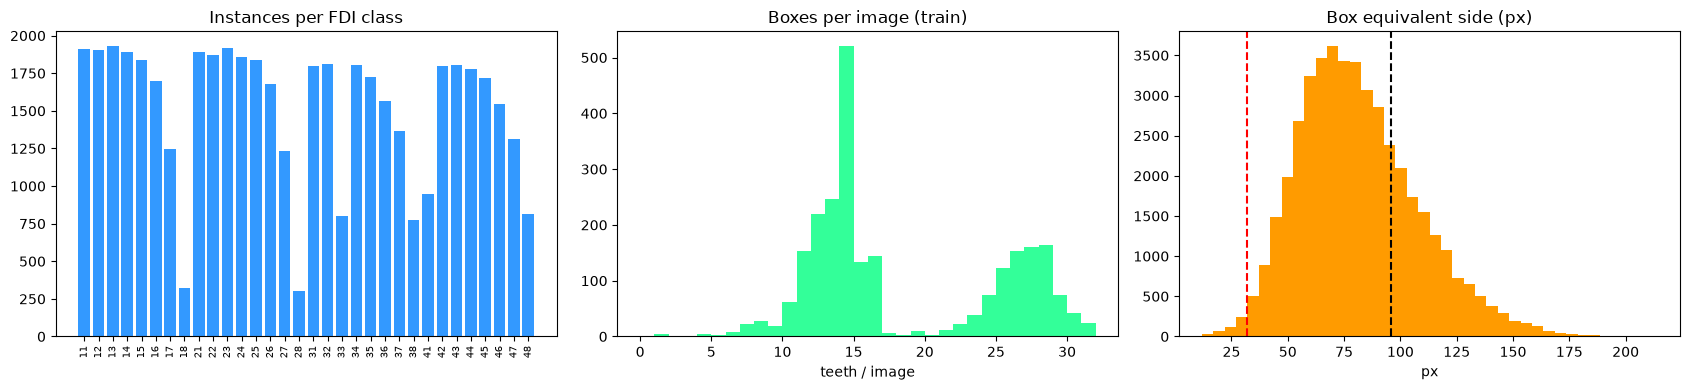

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
counts = [sum(eda[s]['cls'].get(i, 0) for s in eda) for i in range(NUM_CLASSES)]
ax[0].bar(CLASSES, counts, color="#3399ff"); ax[0].set_title("Instances per FDI class")
ax[0].tick_params(axis='x', labelrotation=90, labelsize=7)
mx = max(eda['train']['bpi']) if eda['train']['bpi'] else 1
ax[1].hist(eda['train']['bpi'], bins=range(0, mx + 2), color="#33ff99")
ax[1].set_title("Boxes per image (train)"); ax[1].set_xlabel("teeth / image")
px_side = np.sqrt(np.array(eda['train']['areas'])) * IMGSZ
ax[2].hist(px_side, bins=40, color="#ff9b00")
ax[2].axvline(32, color="r", ls="--"); ax[2].axvline(96, color="k", ls="--")
ax[2].set_title("Box equivalent side (px)"); ax[2].set_xlabel("px")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "eda_overview.png"), dpi=110); plt.show()

## 6 · Augmentation sanity-check — proving flips are off
Left: a train image with FDI labels. Middle: what a horizontal flip would do **if labels were
kept** — the arch order reverses (tooth `11` lands in the `21` slot), which is why we set
`fliplr=0.0`. Right: mild HSV jitter (boxes untouched). Mosaic (not shown) is safe because it
transforms boxes along with the pixels.

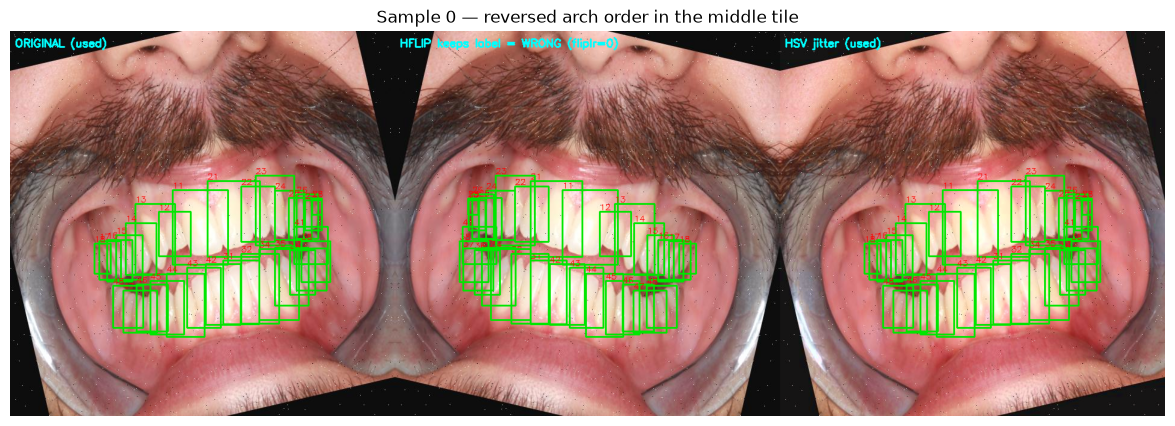

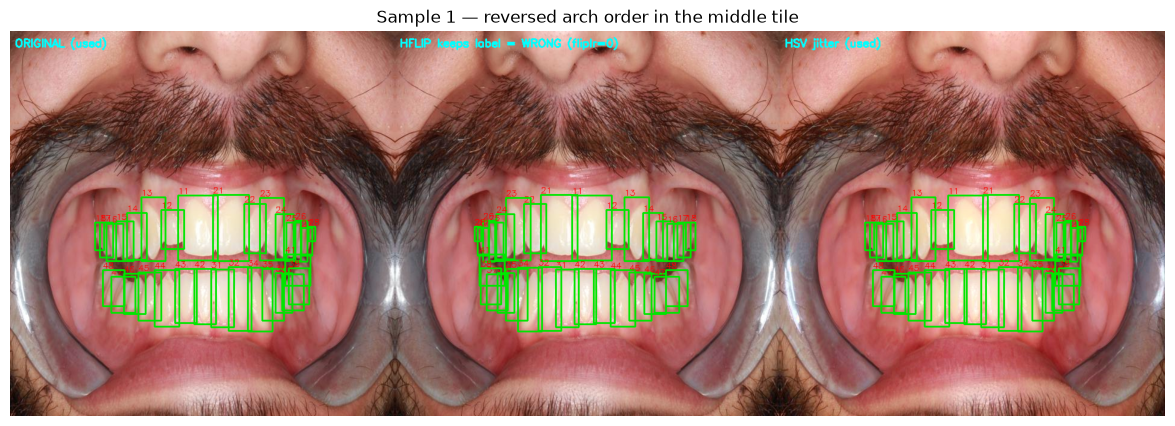

Confirmed: training uses fliplr=0.0/flipud=0.0; boxes stay aligned.


In [10]:
def load_yolo(split, stem_img):
    img = cv2.imread(stem_img); H, W = img.shape[:2]
    lp = stem_img.replace(os.sep+"images"+os.sep, os.sep+"labels"+os.sep)
    lp = os.path.splitext(lp)[0] + ".txt"
    boxes = []
    for ln in open(lp):
        if not ln.strip(): continue
        c, cx, cy, w, h = ln.split(); c = int(c)
        cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        boxes.append([c, cx-w/2, cy-h/2, cx+w/2, cy+h/2])
    return img, boxes

def draw(img, boxes, flip=False):
    vis = img.copy(); W = vis.shape[1]
    if flip: vis = vis[:, ::-1].copy()
    for c, x1, y1, x2, y2 in boxes:
        if flip: x1, x2 = W-x2, W-x1
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 230, 0), 2)
        cv2.putText(vis, CLASSES[c], (int(x1), max(int(y1)-3, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)
    return vis

def hsv_jit(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int16)
    hsv[..., 1] = np.clip(hsv[..., 1]+12, 0, 255); hsv[..., 2] = np.clip(hsv[..., 2]+8, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

imgs = sorted(glob.glob(os.path.join(CLEAN_DIR, "train", "images", "*")),
              key=lambda p: -len(open(p.replace(os.sep+"images"+os.sep, os.sep+"labels"+os.sep)
                                    .rsplit(".",1)[0]+".txt").read().split("\n")))[:2]
for k, ip in enumerate(imgs):
    img, boxes = load_yolo("train", ip)
    a = draw(img, boxes); b = draw(img, boxes, flip=True); c = draw(hsv_jit(img), boxes)
    for im, txt in [(a, "ORIGINAL (used)"), (b, "HFLIP keeps label = WRONG (fliplr=0)"),
                    (c, "HSV jitter (used)")]:
        cv2.putText(im, txt, (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    tiles = [cv2.cvtColor(x, cv2.COLOR_BGR2RGB) for x in (a, b, c)]
    plt.figure(figsize=(20, 5)); plt.imshow(np.hstack(tiles)); plt.axis("off")
    plt.title(f"Sample {k} — reversed arch order in the middle tile"); plt.show()
print("Confirmed: training uses fliplr=0.0/flipud=0.0; boxes stay aligned.")

## 7 · Train YOLO26x (flips disabled)
NMS-free end-to-end model, Ultralytics recipe. The task-specific change is `fliplr=0.0`
(+ `flipud=0.0`). `optimizer=auto` selects MuSGD for a long run; `patience=30` early-stops if
val mAP plateaus for 30 epochs (set above `close_mosaic=15` so the mosaic-off refinement always
runs). Outputs (weights, curves, confusion matrix) go under `WORK/yolo`.

An `on_fit_epoch_end` callback prints a **per-epoch metrics table** after every validation:
overall `mAP50-95 / mAP50 / mAP75 / F1 / Prec / Recall`, then per-class
`AP50-95 / F1 / Prec / Recall` (P/R/F1 at YOLO's best-F1 confidence).

> OOM? lower `BATCH` (64 → 32 → 16) or set `BATCH=-1` for auto.

In [ ]:
from ultralytics import YOLO
YOLO_OUT = os.path.join(WORK, "yolo")
model = YOLO(YOLO_MODEL)

# ---- per-epoch metrics table (overall + per-class), printed after each val ----
# Ultralytics validates every epoch; this callback formats trainer.validator.metrics
# into the same layout as the report image: overall mAP50-95/50/75 + F1/Prec/Recall,
# then per-class AP50-95/F1/Prec/Recall. P/R/F1 are taken at YOLO's best-F1 confidence.
def make_epoch_printer():
    def _cb(trainer):
        box = getattr(getattr(getattr(trainer, "validator", None), "metrics", None), "box", None)
        if box is None: return
        ep = trainer.epoch + 1; tot = trainer.epochs
        mp, mr = float(box.mp), float(box.mr); f1 = 2*mp*mr/(mp+mr+1e-9)
        print(f"\n=== Val (Epoch {ep}/{tot}) — Overall ===")
        hdr = f"{'mAP50-95':>10}{'mAP50':>10}{'mAP75':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print(hdr); print("-"*len(hdr))
        print(f"{box.map:>10.4f}{box.map50:>10.4f}{box.map75:>10.4f}{f1:>10.4f}{mp:>10.4f}{mr:>10.4f}")
        ph = f"{'Class':<8}{'AP50-95':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print("--- Per-class ---"); print(ph); print("-"*len(ph))
        idx = list(box.ap_class_index)
        for c in range(NUM_CLASSES):
            if c in idx:
                k = idx.index(c); p, r, _ap50, ap = box.class_result(k)
                print(f"{CLASSES[c]:<8}{ap:>10.4f}{float(box.f1[k]):>10.4f}{p:>10.4f}{r:>10.4f}")
            else:
                print(f"{CLASSES[c]:<8}{'—':>10}{'—':>10}{'—':>10}{'—':>10}")
    return _cb

model.add_callback("on_fit_epoch_end", make_epoch_printer())

train_results = model.train(
    data=DATA_YAML, epochs=EPOCHS, patience=PATIENCE, imgsz=IMGSZ, batch=BATCH,
    optimizer=OPTIMIZER, seed=SEED, device=0, workers=8,
    project=YOLO_OUT, name="train", exist_ok=True, plots=True,
    **AUG,                                   # flips OFF + mild jitter
)
RUN_DIR = train_results.save_dir if hasattr(train_results, "save_dir") else os.path.join(YOLO_OUT, "train")
BEST = os.path.join(str(RUN_DIR), "weights", "best.pt")
print("Training done. best.pt ->", BEST)
!ls -la {os.path.join(str(RUN_DIR), 'weights')}

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition, 97248MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/intraoral_fdi_yolo_run/dataset_fdi_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.4, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=N

### 7b · Resume training from `last.pt`
Run **either 7 or this** — never both in one kernel. YOLO restores model+optimizer+epoch from
`last.pt`; `epochs` in the original call is the TOTAL, so to train longer first bump `EPOCHS`
in §2 and re-run §7 fresh, or use this cell to finish an interrupted run.

In [ ]:
from ultralytics import YOLO
RUN_DIR = os.path.join(WORK, "yolo", "train")
last_pt = os.path.join(RUN_DIR, "weights", "last.pt")
assert os.path.exists(last_pt), f"missing {last_pt}"
model = YOLO(last_pt)

# same per-epoch metrics table as §7 (overall + per-class), printed after each val
def make_epoch_printer():
    def _cb(trainer):
        box = getattr(getattr(getattr(trainer, "validator", None), "metrics", None), "box", None)
        if box is None: return
        ep = trainer.epoch + 1; tot = trainer.epochs
        mp, mr = float(box.mp), float(box.mr); f1 = 2*mp*mr/(mp+mr+1e-9)
        print(f"\n=== Val (Epoch {ep}/{tot}) — Overall ===")
        hdr = f"{'mAP50-95':>10}{'mAP50':>10}{'mAP75':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print(hdr); print("-"*len(hdr))
        print(f"{box.map:>10.4f}{box.map50:>10.4f}{box.map75:>10.4f}{f1:>10.4f}{mp:>10.4f}{mr:>10.4f}")
        ph = f"{'Class':<8}{'AP50-95':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print("--- Per-class ---"); print(ph); print("-"*len(ph))
        idx = list(box.ap_class_index)
        for c in range(NUM_CLASSES):
            if c in idx:
                k = idx.index(c); p, r, _ap50, ap = box.class_result(k)
                print(f"{CLASSES[c]:<8}{ap:>10.4f}{float(box.f1[k]):>10.4f}{p:>10.4f}{r:>10.4f}")
            else:
                print(f"{CLASSES[c]:<8}{'—':>10}{'—':>10}{'—':>10}{'—':>10}")
    return _cb
model.add_callback("on_fit_epoch_end", make_epoch_printer())

train_results = model.train(resume=True)
BEST = os.path.join(RUN_DIR, "weights", "best.pt")
print("Resumed training done. best.pt ->", BEST)

## 8 · Evaluate on the TEST split (overall + per-class mAP)
Ultralytics `val(split='test')` gives mAP@50 / mAP@50-95 and per-class AP.

In [18]:
from ultralytics import YOLO
best = YOLO(BEST)
metrics = best.val(data=DATA_YAML, split="test", imgsz=IMGSZ, batch=BATCH,
                   project=os.path.join(WORK, "yolo"), name="val_test", exist_ok=True)
test_metrics = {"model": YOLO_MODEL, "weights": BEST, "imgsz": IMGSZ,
                "map50": float(metrics.box.map50), "map50_95": float(metrics.box.map)}
per_class = {}
try:
    maps = metrics.box.maps                       # per-class mAP50-95, indexed by class
    for i, nm in enumerate(CLASSES):
        if i < len(maps): per_class[nm] = {"AP50-95": float(maps[i])}
except Exception as e:
    print("[warn] per-class parse:", e)
test_metrics["per_class"] = per_class
json.dump(test_metrics, open(os.path.join(WORK, "test_metrics.json"), "w"), indent=2)
print(f"mAP50={test_metrics['map50']*100:.1f}  mAP50-95={test_metrics['map50_95']*100:.1f}")
print("per-class AP50-95:", json.dumps(per_class, indent=2))

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition, 97248MiB)
YOLO26x summary (fused): 190 layers, 55,670,508 parameters, 0 gradients, 193.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2029.1±545.0 MB/s, size: 55.3 KB)
val: Scanning /intraoral_fdi_yolo_run/dataset_fdi_yolo/test/labels.cache... 145 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 145/145 50.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s2.1s
                   all        145       2150      0.744      0.732      0.743      0.522
                    11         94         94      0.796      0.894      0.917      0.637
                    12         93         93      0.921       0.88      0.948      0.638
                    13         95         96        0.9      0.885      0.911      0.648
                    14         92         93      0.816     

## 9 · Numbering metrics — *did we put the right FDI number on the tooth?*
Same numbering-specific measures as the RF-DETR notebook: a class-agnostic **detection** P/R
sweep, **exact-FDI** accuracy and **quadrant** accuracy on correctly-localized teeth, and a
top-confusions table. Predictions come from YOLO at conf 0.001 (keep nearly all), GT from the
YOLO test labels.

YOLO26x test infer:   0%|          | 0/145 [00:00<?, ?it/s]

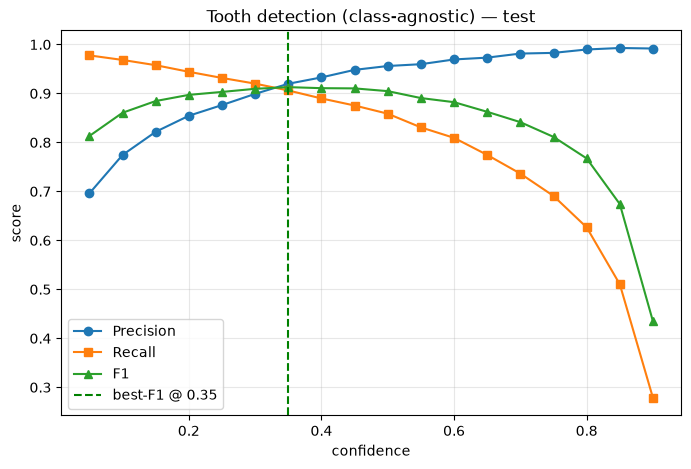

detect best-F1: P=92.0 R=90.6 F1=91.3 @conf=0.35
numbering (matched n=1948): exact FDI acc=83.9%  quadrant acc=96.3%
top confusions (gt -> pred):
   38 -> 37: 13
   31 -> 32: 12
   34 -> 35: 10
   16 -> 17: 9
   47 -> 46: 8
   25 -> 24: 8
   15 -> 16: 7
   46 -> 45: 7
   32 -> 34: 7
   17 -> 16: 7
   27 -> 26: 7
   43 -> 42: 7


In [19]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    a = np.asarray(a, float); b = np.asarray(b, float)
    ix1 = np.maximum(a[:,None,0], b[None,:,0]); iy1 = np.maximum(a[:,None,1], b[None,:,1])
    ix2 = np.minimum(a[:,None,2], b[None,:,2]); iy2 = np.minimum(a[:,None,3], b[None,:,3])
    iw = np.clip(ix2-ix1, 0, None); ih = np.clip(iy2-iy1, 0, None); inter = iw*ih
    aa = (a[:,2]-a[:,0])*(a[:,3]-a[:,1]); ab = (b[:,2]-b[:,0])*(b[:,3]-b[:,1])
    return inter / (aa[:,None] + ab[None,:] - inter + 1e-9)

# cache predictions + GT for every test image
test_imgs = sorted(glob.glob(os.path.join(CLEAN_DIR, "test", "images", "*")))
match_records = []
for ip in tqdm(test_imgs, desc="YOLO26x test infer"):
    H, W = cv2.imread(ip).shape[:2]
    res = best.predict(ip, imgsz=IMGSZ, conf=0.001, verbose=False)[0]
    pb = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else np.zeros((0,4))
    pc = res.boxes.conf.cpu().numpy() if res.boxes is not None else np.zeros((0,))
    pl = res.boxes.cls.cpu().numpy().astype(int) if res.boxes is not None else np.zeros((0,),int)
    gt, gl = [], []
    lp = ip.replace(os.sep+"images"+os.sep, os.sep+"labels"+os.sep); lp = os.path.splitext(lp)[0]+".txt"
    for ln in open(lp):
        if not ln.strip(): continue
        c, cx, cy, w, h = ln.split(); cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        gt.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2]); gl.append(int(c))
    match_records.append((np.asarray(pb,float).reshape(-1,4), np.asarray(pc,float).reshape(-1),
                          np.asarray(pl,int).reshape(-1), np.asarray(gt,float).reshape(-1,4),
                          np.asarray(gl,int).reshape(-1)))

def detect_sweep(conf, iou_thr=0.5):
    tp = fp = fn = 0
    for pb, pc, pl, gt, gl in match_records:
        keep = pc >= conf; pbb = pb[keep]; order = np.argsort(-pc[keep]); pbb = pbb[order]
        if len(gt) == 0: fp += len(pbb); continue
        if len(pbb) == 0: fn += len(gt); continue
        ious = iou_matrix(pbb, gt); matched = np.zeros(len(gt), bool)
        for i in range(len(pbb)):
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]: matched[j] = True; tp += 1
            else: fp += 1
        fn += int(np.sum(~matched))
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return dict(conf=round(float(conf),3), tp=tp, fp=fp, fn=fn,
                precision=float(prec), recall=float(rec), f1=float(2*prec*rec/(prec+rec+1e-9)))

sweep = [detect_sweep(c) for c in np.round(np.arange(0.05, 0.91, 0.05), 2)]
best_f1 = max(sweep, key=lambda d: d["f1"])

def numbering_accuracy(conf, iou_thr=0.5):
    correct = quad_correct = total = 0; confusion = Counter()
    for pb, pc, pl, gt, gl in match_records:
        keep = pc >= conf; pbb = pb[keep]; pcc = pc[keep]; pll = pl[keep]
        order = np.argsort(-pcc); pbb = pbb[order]; pll = pll[order]
        if len(gt) == 0 or len(pbb) == 0: continue
        ious = iou_matrix(pbb, gt); matched = np.zeros(len(gt), bool)
        for i in range(len(pbb)):
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]:
                matched[j] = True; total += 1
                gnm = CLASSES[int(gl[j])]; pnm = CLASSES[int(pll[i])]
                if pnm == gnm: correct += 1
                else: confusion[(gnm, pnm)] += 1
                if pnm[:1] == gnm[:1]: quad_correct += 1
    return dict(matched=total, exact_acc=correct/max(total,1),
                quadrant_acc=quad_correct/max(total,1), top_confusions=confusion.most_common(12))

num_at_bestf1 = numbering_accuracy(best_f1["conf"])
numbering = {"detect_sweep": sweep, "detect_best_f1": best_f1, "numbering_at_best_f1": num_at_bestf1}
json.dump(numbering, open(os.path.join(WORK, "numbering_metrics.json"), "w"), indent=2, default=str)

cs = [d["conf"] for d in sweep]
plt.figure(figsize=(8,5))
plt.plot(cs, [d["precision"] for d in sweep], "o-", label="Precision")
plt.plot(cs, [d["recall"] for d in sweep], "s-", label="Recall")
plt.plot(cs, [d["f1"] for d in sweep], "^-", label="F1")
plt.axvline(best_f1["conf"], color="g", ls="--", label=f"best-F1 @ {best_f1['conf']}")
plt.xlabel("confidence"); plt.ylabel("score"); plt.title("Tooth detection (class-agnostic) — test")
plt.legend(); plt.grid(alpha=0.3)
os.makedirs(os.path.join(WORK, "plots"), exist_ok=True)
plt.savefig(os.path.join(WORK, "plots", "detection_pr.png"), dpi=120, bbox_inches="tight"); plt.show()
print(f"detect best-F1: P={best_f1['precision']*100:.1f} R={best_f1['recall']*100:.1f} "
      f"F1={best_f1['f1']*100:.1f} @conf={best_f1['conf']}")
print(f"numbering (matched n={num_at_bestf1['matched']}): exact FDI acc={num_at_bestf1['exact_acc']*100:.1f}%  "
      f"quadrant acc={num_at_bestf1['quadrant_acc']*100:.1f}%")
print("top confusions (gt -> pred):")
for (g, p), nn in num_at_bestf1["top_confusions"]:
    print(f"   {g} -> {p}: {nn}")

## 10 · Save annotated test predictions
At the best-F1 detection confidence — annotated images plus a JSON of per-image detections.

In [20]:
PRED_CONF = numbering["detect_best_f1"]["conf"]
pred_dir = os.path.join(WORK, "predictions_test"); os.makedirs(pred_dir, exist_ok=True)
pred_dump = {}
for ip in tqdm(test_imgs, desc="save predictions"):
    res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False)[0]
    annotated = res.plot()                      # BGR ndarray with boxes+labels
    name = os.path.basename(ip); cv2.imwrite(os.path.join(pred_dir, name), annotated)
    dets = []
    if res.boxes is not None:
        for b, c, s in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy().astype(int),
                           res.boxes.conf.cpu().numpy()):
            dets.append({"fdi": CLASSES[int(c)], "conf": float(s), "xyxy": [float(v) for v in b]})
    pred_dump[name] = dets
json.dump(pred_dump, open(os.path.join(pred_dir, "_predictions.json"), "w"), indent=2)
print("Saved annotated test predictions ->", pred_dir, f"(conf={PRED_CONF})")

save predictions:   0%|          | 0/145 [00:00<?, ?it/s]

Saved annotated test predictions -> /intraoral_fdi_yolo_run/predictions_test (conf=0.35)


## 11 · Training graphs + qualitative check
Ultralytics writes `results.png` (loss/mAP curves), `confusion_matrix.png`, and PR curves into
the run dir.

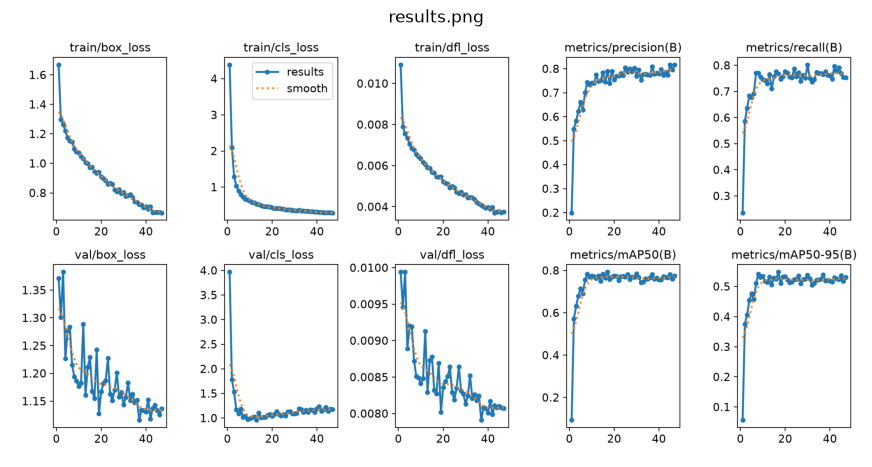

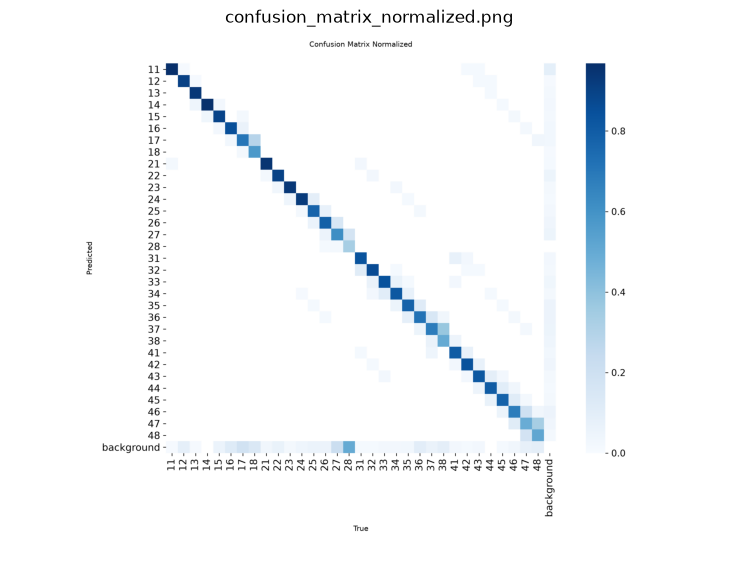

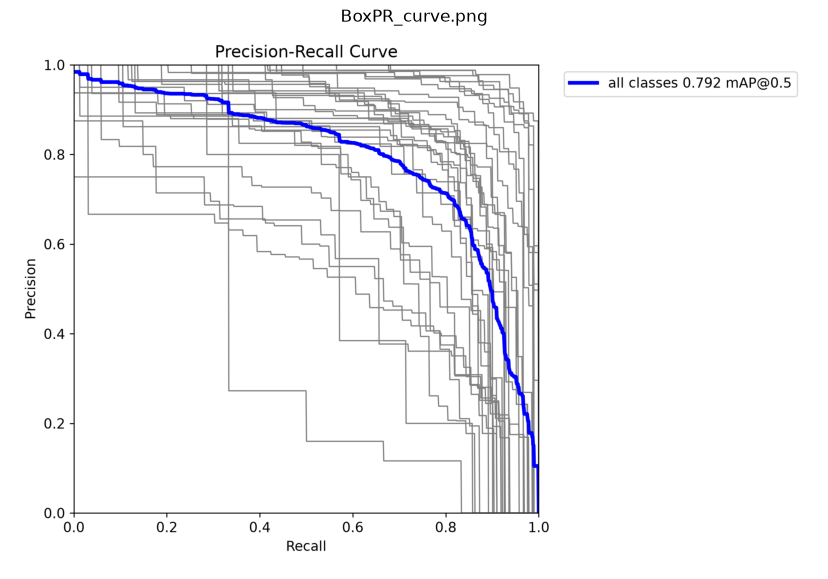

In [21]:
for fnm in ["results.png", "confusion_matrix_normalized.png", "BoxPR_curve.png"]:
    p = os.path.join(str(RUN_DIR), fnm)
    if os.path.exists(p):
        plt.figure(figsize=(11, 7)); plt.imshow(plt.imread(p)); plt.axis("off")
        plt.title(fnm); plt.show()
    else:
        print("missing", p)

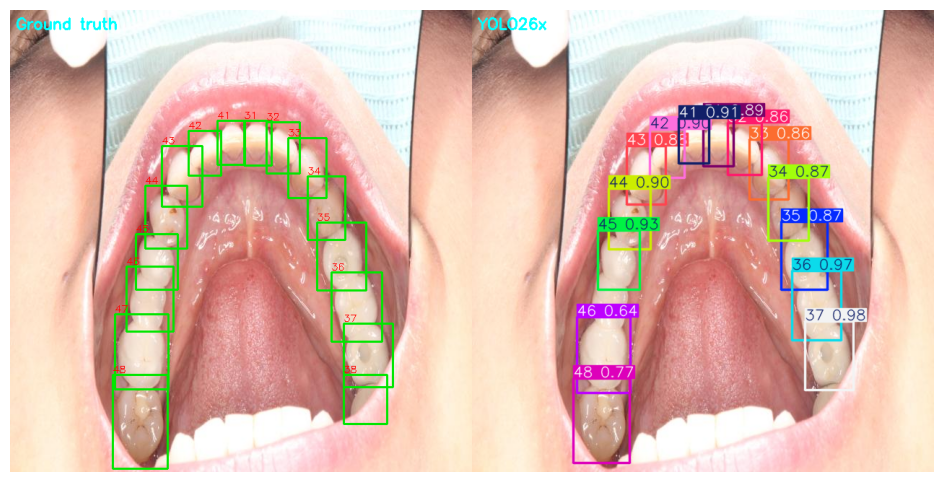

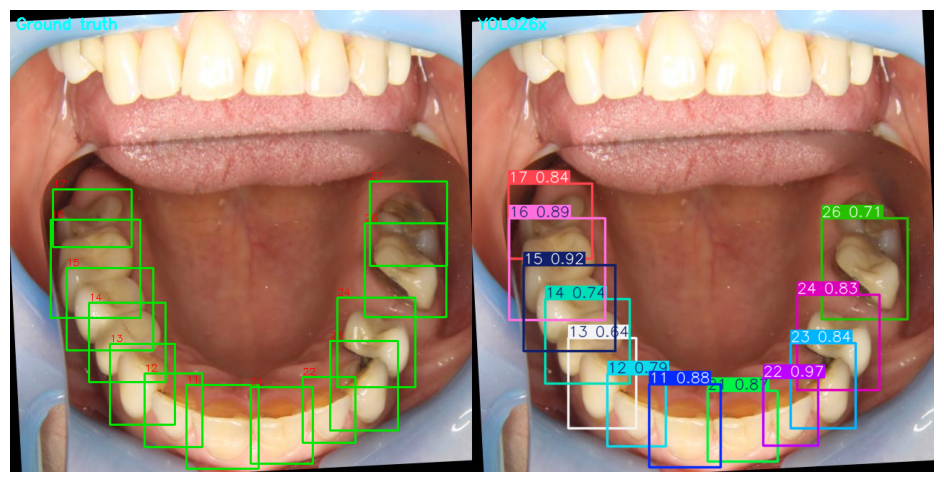

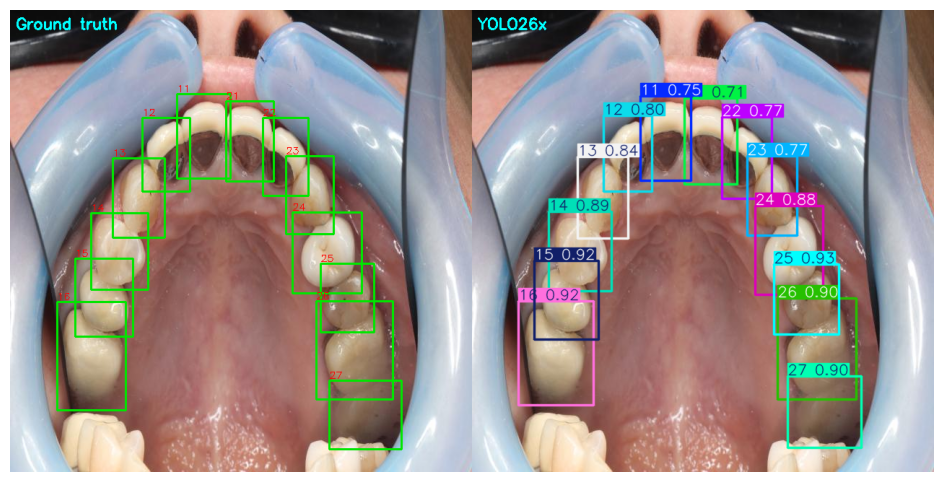

In [22]:
# GT vs prediction on a few test images
for ip in test_imgs[:3]:
    img, boxes = load_yolo("test", ip)
    gt = draw(img, boxes)
    res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False)[0]
    pr = res.plot()
    cv2.putText(gt, "Ground truth", (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
    cv2.putText(pr, "YOLO26x", (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
    plt.figure(figsize=(20, 6))
    plt.imshow(np.hstack([cv2.cvtColor(gt, cv2.COLOR_BGR2RGB), cv2.cvtColor(pr, cv2.COLOR_BGR2RGB)]))
    plt.axis("off"); plt.show()

## 12 · Save the model + a results summary

In [23]:
shutil.copy2(BEST, os.path.join(WORK, "best.pt"))
summary = {"model": YOLO_MODEL, "task": "intraoral FDI tooth numbering (YOLO)",
           "imgsz": IMGSZ, "epochs": EPOCHS, "patience": PATIENCE, "batch": BATCH, "optimizer": OPTIMIZER,
           "classes": CLASSES, "augmentation": AUG,
           "test_metrics": test_metrics,
           "numbering": {"detect_best_f1": numbering["detect_best_f1"],
                         "numbering_at_best_f1": numbering["numbering_at_best_f1"]},
           "artifacts": {"weights": os.path.join(WORK, "best.pt"),
                         "test_metrics": os.path.join(WORK, "test_metrics.json"),
                         "numbering_metrics": os.path.join(WORK, "numbering_metrics.json"),
                         "predictions": os.path.join(WORK, "predictions_test"),
                         "run_dir": str(RUN_DIR)}}
json.dump(summary, open(os.path.join(WORK, "summary.json"), "w"), indent=2, default=str)
print(json.dumps(summary["test_metrics"], indent=2))
print(json.dumps(summary["numbering"], indent=2, default=str))
print("\nAll artifacts under:", WORK)
for p in sorted(glob.glob(os.path.join(WORK, "*"))):
    print("  ", os.path.basename(p))

{
  "model": "yolo26x.pt",
  "weights": "/intraoral_fdi_yolo_run/yolo/train/weights/best.pt",
  "imgsz": 640,
  "map50": 0.7429819183931181,
  "map50_95": 0.5215341099247548,
  "per_class": {
    "11": {
      "AP50-95": 0.6370983301190722
    },
    "12": {
      "AP50-95": 0.6379949703734337
    },
    "13": {
      "AP50-95": 0.6477335569545627
    },
    "14": {
      "AP50-95": 0.6019731150280369
    },
    "15": {
      "AP50-95": 0.5300759551783158
    },
    "16": {
      "AP50-95": 0.4618507889882716
    },
    "17": {
      "AP50-95": 0.47963040012655866
    },
    "18": {
      "AP50-95": 0.20837597139968222
    },
    "21": {
      "AP50-95": 0.6877427287818436
    },
    "22": {
      "AP50-95": 0.6237347916856549
    },
    "23": {
      "AP50-95": 0.6603344259222635
    },
    "24": {
      "AP50-95": 0.5934846331212612
    },
    "25": {
      "AP50-95": 0.5366374654750962
    },
    "26": {
      "AP50-95": 0.5654468181791492
    },
    "27": {
      "AP50-95": 0.51245

## 13 · Notes & levers
**Implemented**
1. **YOLO26x** (NMS-free end-to-end), fine-tuned from COCO-pretrained weights. ✅
2. **Flips disabled** (`fliplr=0.0, flipud=0.0`) — the core fix for positional FDI labels. ✅
3. **Three sources merged BY SOURCE PHOTO** (Lower→Front→Main) — supplies the correct
   `33`/`41`; leak-free re-split by photo; junk (`327`,`56`) dropped. ✅
4. **Stratified split + rare-class oversampling** — every class (incl. 18/28) in all splits;
   wisdom-tooth train photos repeated (LVIS RFS). ✅
5. **QA guard** hard-fails on any class with 0 train boxes AND 0 valid/test boxes. ✅
6. **Numbering-specific metrics** — exact-FDI / quadrant accuracy + detection sweep. ✅

**Push higher if needed**
* Train longer (raise `EPOCHS`); keep `close_mosaic` so the last epochs refine without mosaic.
* Mosaic is on (it does NOT corrupt labels — boxes are transformed with the pixels). If small
  third molars regress, try `mosaic=0.5` or a larger `IMGSZ` (note the source is natively 640²,
  so upscaling mostly interpolates).
* `top_confusions` shows neighbour (14↔15) vs wrong-side (14↔24) errors.

**vs the RF-DETR-2XL notebook** — identical data/merge/metrics, so the two are directly
comparable. YOLO26x is far faster to train/deploy and NMS-free; RF-DETR-2XL is heavier and may
edge ahead on dense small-object mAP. Run both, compare `test_metrics.json` + `numbering`.

**Caveats** — residual silent-negative for `33` in Front/lateral photos (only Lower labels it);
the clean fix is to re-annotate `33`/`41` in the Front/Main projects and regenerate. YOLO26
weights are AGPL-3.0 (Ultralytics) — check licensing for your use.